In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
import seaborn as sns

from connectivity.curves import CURVES


%load_ext autoreload
%autoreload 2
%aimport connectivity

base_path = "D:/data_paper"

responses_dict = [
    {
        "patient_id": "EL028",
        "stim_channel_pos": "OF-R-1",
        "stim_channel_neg": "OF-R-2",
        "response_channel_pos": "OF-R-3",
        "response_channel_neg": "OF-R-4",
    },
    {
        "patient_id": "EL019",
        "stim_channel_pos": "pIL-2",
        "stim_channel_neg": "pIL-3",
        "response_channel_pos": "pIL-4",
        "response_channel_neg": "pIL-5",
    }
]

SOURCE = "output" #"publish_data/paper" # "output"
CLEAN_DATA_FILE = "out/clean_CR_IO/bad_responses_dict.json"
RESPONSES_FILE = f"../{SOURCE}/significant_responses/response_channels_lf.json"
BASELINE_CORRECTION = True
SNR_COLUMN = "snr"

def format_p(p):
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"


Stim: OF-R-1-OF-R-2 (S_suborbital), Resp: OF-R-3-OF-R-4 (S_orbital_med-olfact)
Stim: pIL-2-pIL-3 (S_circular_insula_inf), Resp: pIL-4-pIL-5 (S_circular_insula_inf)
xmin 0.0 xmax 5.296874999999999


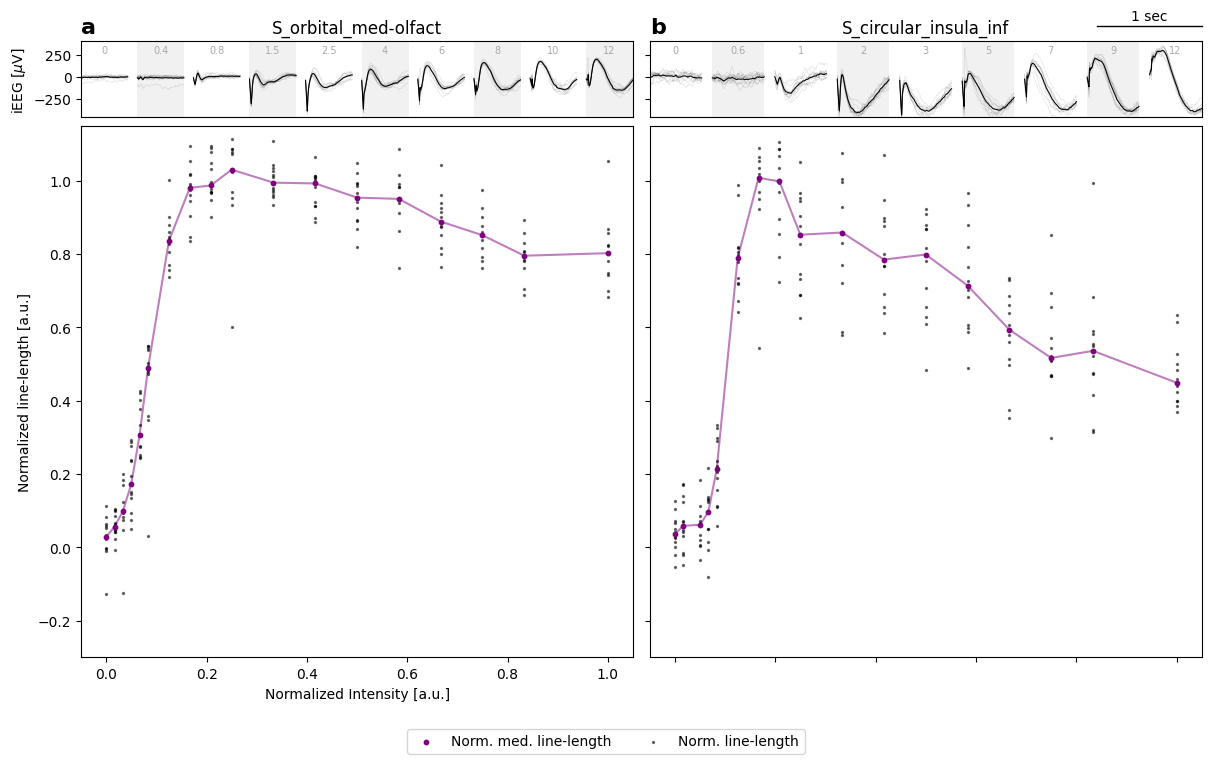

In [2]:
# raw traces
from matplotlib.legend_handler import HandlerTuple
from matplotlib.legend_handler import HandlerTuple
from matplotlib.patches import Rectangle
import scipy
from connectivity.analyze import (
    calculate_continuous_line_length,
    filter_logs,
    fit_curve,
    normalize_ll_values,
)
from connectivity.enums import SleepStage
from connectivity.load import MultipleHDFResponseLoader, get_h5_names_of_patient, parsed_list_to_numpy_array
from connectivity.analyze import calculate_model_performance
import matplotlib.lines as mlines

def format_p(p):
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"

responses_df = pd.read_json(RESPONSES_FILE)


x_fit = np.linspace(0, 1, 1000)


def plot_stimulation_response_curve(
    response_index,
    ax_u,
    ax_ll,
):
    patient_id = responses_dict[response_index]["patient_id"]
    stim_channel_name_pos = responses_dict[response_index]["stim_channel_pos"]
    stim_channel_name_neg = responses_dict[response_index]["stim_channel_neg"]
    stim_channel_name = stim_channel_name_pos + "-" + stim_channel_name_neg
    response_channel_name_pos = responses_dict[response_index]["response_channel_pos"]
    response_channel_name_neg = responses_dict[response_index]["response_channel_neg"]
    response_channel_name = response_channel_name_pos + "-" + response_channel_name_neg

    names_h5 = get_h5_names_of_patient(base_path, patient_id, protocol="CR")
    path_lookup = f"{base_path}/{patient_id}/Electrodes/Lookup.xlsx"
    paths_h5 = [f"{base_path}/{patient_id}/Electrophy/{name}.h5" for name in names_h5]
    paths_logs = [f"{base_path}/{patient_id}/out/{name}_logs.csv" for name in names_h5]
    path_excluded_responses = f"{base_path}/{patient_id}/{CLEAN_DATA_FILE}"

    mrl = MultipleHDFResponseLoader(
        paths_h5=paths_h5,
        paths_logs=paths_logs,
        recording_names=names_h5,
        path_lookup=path_lookup,
        path_excluded_responses=path_excluded_responses,
    )

    logs = mrl.get_logs()   

    if responses_dict[response_index].get("response_channel_path") is not None:
        response_channel_path = responses_dict[response_index]["response_channel_path"]
    else:
        response_channel_path = mrl.get_channel_paths_from_names(
            channel_names=[response_channel_name]
        )[0]

    io_intensities = (
        logs[logs["type"] == "CR_IO"]["Int_prob"].drop_duplicates().tolist()
    )
    io_intensities.sort()
    io_intensities.insert(0, 0)

    y_fits = {}
    exis = {}
    result_dict = responses_df[
        (responses_df["patient_id"] == patient_id) &
        (responses_df["stim_channel_name"] == stim_channel_name) &
        (responses_df["response_channel_name"] == response_channel_name)
    ].squeeze()
    
    # RAW TRACES
    id_matrix = result_dict["id_matrix"]
    id_matrix = np.array(id_matrix)  # shape: n_intensities, n_replications
    ind_matrix = mrl.get_inds_from_stim_ids(id_matrix)
    
    gap_sec = 0.1  # seconds between chunks
    gap = int(round(gap_sec * mrl.f_sample))
    ll_window_start = round(
        1 * mrl.f_sample
    )  # we only want to have the [0, 0.5s] window to display, as it is used for LL calculation
    ll_window_end = round(1.5 * mrl.f_sample)
    chunk_len = ll_window_end - ll_window_start  # traces.shape[3]
    total_chunks = id_matrix.shape[0] // 2 + 1

    # Plot each chunk with color-coded significance
    for j in range(total_chunks):
        if j == 0:
            # remove the -0.6s in the end of every index that indicates baseline
            cleaned_ids = [s.replace("-0.6s", "") for s in id_matrix[j]]
            cleaned_inds = mrl.get_inds_from_stim_ids(cleaned_ids)

            traces = mrl.get_responses(
                stim_indices=cleaned_inds,
                response_channel_paths=[response_channel_path],
                t_start=-1-0.6,
                t_stop=1-0.6,
                overwrite_excluded_recordings=True, 
            ).squeeze(
                1
            )  # shape: n_replications, 1, n_time,

            traces_chunk = traces[:, ll_window_start:ll_window_end]
        else:
            max_j = min(2*j, id_matrix.shape[0]-1)
            traces = mrl.get_responses(
                stim_indices=ind_matrix[max_j],
                response_channel_paths=[response_channel_path],
                # overwrite_excluded_recordings=exclude_responses,
                t_start=-1,
                t_stop=1,
                overwrite_excluded_recordings=True,
            ).squeeze(
                1
            )  # shape: n_replications, 1, n_time, remove middle dim
            traces_chunk = traces[:, ll_window_start:ll_window_end]
        avg_trace_chunk = np.nanmean(traces_chunk, axis=0)  # shape: n_time

        start_idx = j * chunk_len
        end_idx = (j + 1) * chunk_len
        offset_chunk = j * (chunk_len + gap)
        time_chunk = (np.arange(chunk_len) + offset_chunk) / mrl.f_sample

        for trace in traces_chunk:
            ax_u.plot(time_chunk, trace, color="black", alpha=0.1, linewidth=0.5)
        ax_u.plot(
            time_chunk,
            avg_trace_chunk,
            color="black",
            linewidth=0.75,
        )

        start = offset_chunk / mrl.f_sample
        end = (offset_chunk + chunk_len) / mrl.f_sample
        ax_u.axvspan(
            start,
            end,
            facecolor=("lightgray" if j % 2 else "white"),
            alpha=0.3,
            zorder=0,
        ) 
    # stim annotation
    y_axes = 0.95
    for j in range(total_chunks):
        max_j = min(2*j, id_matrix.shape[0]-1)
        offset_chunk = j * (chunk_len + gap)
        start = offset_chunk / mrl.f_sample
        end = (offset_chunk + chunk_len) / mrl.f_sample
        x_center = 0.5 * (start + end)
        ax_u.text(
            x_center,
            y_axes,
            f"{io_intensities[max_j]:.2g}",
            ha="center",
            va="top",
            color="darkgray",
            fontsize=7,
            transform=ax_u.get_xaxis_transform(),  # x=data, y=axes
        )
    ymin, ymax = ax_u.get_ylim()
    headroom = 0.1 * (ymax - ymin)  # fraction of current range
    ax_u.set_ylim(ymin, ymax + headroom)
    ax_u.margins(x=0, y=0)

    # STIMULATION RESPONSE CURVE
    norm_intensities = np.array(io_intensities) / max(io_intensities)
    ll_values = parsed_list_to_numpy_array(result_dict["ll_values"])
    norm_med_lls = parsed_list_to_numpy_array(result_dict["norm_med_lls"])
    med_ll_values = np.nanmedian(ll_values, axis=1)

    shared_ll_min = 0
    shared_ll_max = np.nanpercentile(med_ll_values, 95, axis=0)
    norm_lls = normalize_ll_values(
        ll_values=parsed_list_to_numpy_array(ll_values),
        max=shared_ll_max,
        min=shared_ll_min,
        use_min=True,
        axis=0,
    )

    ax_ll.scatter(
        norm_intensities, norm_med_lls, color="purple", s=10, label=f"Norm. med. line-length", zorder=7
    )
    ax_ll.plot(norm_intensities, norm_med_lls, color="purple", alpha=0.5, zorder=5)
    for j in range(norm_lls.shape[1]):
        ax_ll.scatter(norm_intensities, norm_lls[:, j], color="black", alpha=0.5, s=2, zorder=6, label=f"Norm. line-length" if j==0 else "_nolegend_")


    if response_index == 0:
        ax_ll.set_ylabel("Normalized line-length [a.u.]")
        ax_ll.set_xlabel("Normalized Intensity [a.u.]")
        ax_u.set_ylabel("iEEG $\\left[\\mu \\mathrm{V}\\right]$")
    else:
        plt.setp(ax_ll.get_yticklabels(), visible=False)
        plt.setp(ax_ll.get_xticklabels(), visible=False)
        plt.setp(ax_u.get_yticklabels(), visible=False)

    ax_u.set_xticks([])

    destr_label = mrl.get_destrieux_labels_from_names(channel_names=[response_channel_name], short_form=True)[0]
    ax_u.set_title(f"{destr_label}")
    destr_label_stim = mrl.get_destrieux_labels_from_names(channel_names=[stim_channel_name], short_form=True)[0]
    print(f"Stim: {stim_channel_name} ({destr_label_stim}), Resp: {response_channel_name} ({destr_label})")
            
centralized_legend_handles = []
centralized_legend_labels = []

fig = plt.figure(figsize=(12, 7), constrained_layout=True)
gs = GridSpec(
    2, 2, figure=fig, height_ratios=[1, 7]
)

ax_au = fig.add_subplot(gs[0, 0])
ax_al = fig.add_subplot(gs[1, 0])
plot_stimulation_response_curve(
    response_index=0,
    ax_u=ax_au,
    ax_ll=ax_al,
)
ax_au.set_title("a", loc="left", fontsize=16, fontweight="bold")

ax_bu = fig.add_subplot(gs[0, 1], sharey=ax_au)
ax_bl = fig.add_subplot(gs[1, 1], sharey=ax_al, sharex=ax_al)
plot_stimulation_response_curve(
    response_index=1,
    ax_u=ax_bu,
    ax_ll=ax_bl,
)
ax_bu.set_title("b", loc="left", fontsize=16, fontweight="bold")
# add time scale
pad_frac = 0
y_frac = 1.2

xmin, xmax = ax_bu.get_xlim()
print("xmin", xmin, "xmax", xmax)
x1 = xmax - pad_frac * (xmax - xmin)  # right-aligned
x0 = x1 - 1 # max length - 1 sec
ax_bu.plot(
    [x0, x1], [y_frac, y_frac],
    transform=ax_bu.get_xaxis_transform(),
    color="black", lw=1,
    clip_on=False
)
ax_bu.text(
    (x0 + x1) / 2, y_frac + 0.04,
    f"1 sec",
    transform=ax_bu.get_xaxis_transform(),
    ha="center", va="bottom",
    clip_on=False
)

#destr_label = mrl.get_destrieux_labels_from_names(channel_names=[response_channel_pair[0] + "-" + response_channel_pair[1]], short_form=True)[0]
#ax_au.set_title(f"{destr_label}")
#ax_au.set_title(f"{friendly_response_channel_name} ({destr_label})")
ax_al.set_ylim([-0.3, 1.15])

handles, labels = ax_al.get_legend_handles_labels()
centralized_legend_handles.extend(handles)
centralized_legend_labels.extend(labels)


fig.legend(
    centralized_legend_handles,
    centralized_legend_labels,
    loc="lower center",
    ncol=5,
    bbox_to_anchor=(0.5, -0.08),
    frameon=True,
)
# legend_2 = fig.legend(
#     participant_handles,
#     participant_labels,
#     loc="lower center",
#     ncol=2,
#     bbox_to_anchor=(0.5, -0.08),
#     frameon=False,
# )


plt.savefig("../output/figures/sfigure10.pdf", bbox_inches='tight', dpi=300)
plt.savefig("../output/figures/sfigure10.svg", bbox_inches='tight', dpi=300)
plt.show()